In [87]:
import requests 
import numpy as np
import pandas as pd
import pprint
from bs4 import BeautifulSoup
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

In [88]:
male_url = "https://murderpedia.org/male.A/index.A.htm"
female_url = "https://murderpedia.org/female.A/index.A.htm"

male_response = requests.get(male_url, headers=headers)
female_response = requests.get(female_url, headers=headers)

male_soup = BeautifulSoup(male_response.text, "html.parser")
female_soup = BeautifulSoup(female_response.text, "html.parser")

male_response 
female_response

<Response [200]>

In [89]:
#I am finding all names (male and females and identifying them by gender)
def new (): #Using this to create a new variable
    names = []

    for tag in soup.find_all('a', href=True):
        href = tag.get('href')
        name = " ".join(tag.get_text(" ", strip=True).split())

        if (
            href.endswith(".htm")
            and "index" not in href
            and name.lower() not in ["last updates", "home", ""] #using this so I only get the names and gender from the page
        ):
            names.append(name)

    return pd.DataFrame({
        "name": names,
        "gender": gender
    })

# Creating both datasets
male_df = create_df(male_soup, "Male")
female_df = create_df(female_soup, "Female")

print(len(male_df), len(female_df))

220 50


In [90]:
#Next I want to combine the both female and male using pd.concat to get this result https://www.geeksforgeeks.org/python/pandas-concat-function-in-python/
final_df = pd.concat([male_df, female_df], axis=0, ignore_index=True) 
#using the axis and ignore code so i can get all the rows https://codegive.com/blog/pandas_ignore_index_true.php
final_df.head(270)

,name,gender
0,Abbas Baqir,Male
1,ABBAS,Male
2,Burton W. ABBOTT,Male
3,Jack Henry ABBOTT,Male
4,William Keith ABBOTT,Male
...,...,...
265,Gunn-Britt ASHFIELD,Female
266,Lisl AUMAN,Female
267,Zakieya Latrice AVERY,Female
268,Asuncion AVILA-VILLA,Female


In [91]:
#Moving onto my next variable which is method of killing for both male and female offenders 

In [92]:
from urllib.parse import urljoin #https://docs.python.org/3/library/urllib.parse.html

# Making it into a dictionary so it's less lines
method_dict = {
    "Poisoning": ["poison", "arsenic", "cyanide"],
    "Shooting": ["shoot", "gun", "shot", "rifle"],
    "Stabbing": ["stab", "knife"],
    "Strangulation": ["strangl", "suffocat"],
    "Bludgeoning/Beating": ["bludgeon", "beat", "hammer", "club"],
    "Axe/Hatchet": ["axe", "hatchet"],
    "Drowning": ["drown"],
    "Burning/Fire": ["fire", "burn"]
}

def get_methods(soup, url, df):
    links = [
        urljoin(url, tag["href"])
        for tag in soup.find_all("a", href=True)
        if tag["href"].endswith(".htm")
        and "index" not in tag["href"]
    ]

    links = links[:len(df)]
    methods = []

    for link in links:
        try:
            text = BeautifulSoup(
                requests.get(link, headers=headers).text,
                "html.parser"
            ).get_text(" ", strip=True).lower()

            method = next(
                (m for m, words in method_dict.items()
                 if any(word in text for word in words)),
                "Unknown"
            )

            methods.append(method)

        except:
            methods.append("Unknown")

    return methods, links

# Running for both male and female pages
male_methods, male_links = get_methods(male_soup, male_url, male_df)
female_methods, female_links = get_methods(female_soup, female_url, female_df)

# Adding methods to dataframes
male_df["method"] = male_methods
female_df["method"] = female_methods

print(len(male_df), len(male_links), len(male_methods))
print(len(female_df), len(female_links), len(female_methods))

220 220 220
50 50 50


In [93]:
#Combing methods with the names and gender 
final_df = pd.concat([male_df, female_df], ignore_index=True)
print(final_df.to_string())

                             name  gender               method
0                     Abbas Baqir    Male             Shooting
1                           ABBAS    Male             Shooting
2                Burton W. ABBOTT    Male            Poisoning
3               Jack Henry ABBOTT    Male             Stabbing
4            William Keith ABBOTT    Male             Shooting
5                   Azad ABDULLAH    Male             Stabbing
6            Herisch Ali ABDULLAH    Male             Shooting
7                    Ricky ABEYTA    Male             Shooting
8                 Roderick ABEYTA    Male             Shooting
9         Nathaniel Jamal ABRAHAM    Male             Shooting
10                Myer ABRAMOVICH    Male             Stabbing
11                          Elias    Male            Poisoning
12                      ABUELAZAM    Male            Poisoning
13    Saber & Mahmoud ABU-EL-ULLA    Male             Shooting
14                Mumia ABU-JAMAL    Male            Po

In [95]:
#Next I am adding my orginial variable which is violent vs nonviolent
violent_methods = ["Shooting", "Stabbing", "Strangulation","Bludgeoning/Beating", "Axe/Hatchet","Drowning", "Burning/Fire"]

violent_vs_nonviolent = ["Non-violent" if m == "Poisoning"
    else "Violent" if m in violent_methods
    else "Unknown"
    for m in final_df["method"] #nonviolent equals poisoning 
]

In [96]:
#Combining this with my previous variables 
final_df["violent_vs_nonviolent"] = violent_vs_nonviolent
print(final_df[["name", "gender", "method", "violent_vs_nonviolent"]].head(270).to_string())

                             name  gender               method violent_vs_nonviolent
0                     Abbas Baqir    Male             Shooting               Violent
1                           ABBAS    Male             Shooting               Violent
2                Burton W. ABBOTT    Male            Poisoning           Non-violent
3               Jack Henry ABBOTT    Male             Stabbing               Violent
4            William Keith ABBOTT    Male             Shooting               Violent
5                   Azad ABDULLAH    Male             Stabbing               Violent
6            Herisch Ali ABDULLAH    Male             Shooting               Violent
7                    Ricky ABEYTA    Male             Shooting               Violent
8                 Roderick ABEYTA    Male             Shooting               Violent
9         Nathaniel Jamal ABRAHAM    Male             Shooting               Violent
10                Myer ABRAMOVICH    Male             Stabbing   

In [139]:
# Next I will be adding the number of victims each offender has and the location of where the crime took place

from io import StringIO
import re

# Function to get victim tables
def get_victim_table(url, gender):
    html = requests.get(url, headers=headers).text
    tables = pd.read_html(StringIO(html)) #https://stackoverflow.com/questions/77748143/futurewarning-passing-literal-html-to-read-html-is-deprecated-and-will-be-rem


    # The victim info is from table 9:
    # column 1 = names, column 3 = number of victims, column 4 = location
    df = tables[9][[1, 3, 4]].copy()
    df.columns = ["name", "victims", "location"]

    df = (
        df.dropna() #using this to remove missing values
          .query("name != 'Name'") #https://note.nkmk.me/en/python-pandas-query/ (used this to get the query code)
    )

    df["name"] = (
        df["name"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    ) #Cleans the offender names and then converts values into text;removes extra spaces/tabs/new lines also removes spaces at the beginning or end.

    df["victims"] = df["victims"].astype(str).str.strip()

    df["location"] = (
        df["location"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )  #Cleans the location and then converts values into text;removes extra spaces/tabs/new lines also removes spaces at the beginning or end.

    df["gender"] = gender

    return df

# Creating male and female victim tables
male_table = get_victim_table("https://murderpedia.org/male.A/index.A.htm","Male")

female_table = get_victim_table("https://murderpedia.org/female.A/index.A.htm","Female")

# Combining male and female victim tables
victim_table = pd.concat([male_table, female_table], ignore_index=True)

# Combining victim/location info with method info
final_df = victim_table.merge(final_df[["name", "method", "violent_vs_nonviolent"]])

print(final_df[["name", "gender", "method", "violent_vs_nonviolent", "victims", "location"]].head(270).to_string())

                             name  gender               method violent_vs_nonviolent    victims                location
0                Burton W. ABBOTT    Male            Poisoning           Non-violent          1         California, USA
1               Jack Henry ABBOTT    Male             Stabbing               Violent          2      Utah/New York, USA
2            William Keith ABBOTT    Male             Shooting               Violent          1             New Zealand
3                   Azad ABDULLAH    Male             Stabbing               Violent          1              Idaho, USA
4            Herisch Ali ABDULLAH    Male             Shooting               Violent          1                 Germany
5                    Ricky ABEYTA    Male             Shooting               Violent          7         New Mexico, USA
6                 Roderick ABEYTA    Male             Shooting               Violent          1             Nevada, USA
7         Nathaniel Jamal ABRAHAM    Mal

In [170]:
#Grouping by location and gender and method to see if location impacts method
#But first I am going to make a USA variable since currently it shows up as states
final_df["usa_location"] = ["USA" if "USA" in str(x)else "Non-USA"for x in final_df["location"]]

# Grouping USA vs Non-USA by gender and method type
usa_gender_method = (final_df.groupby(["usa_location", "gender", "method"]).size().reset_index(name="count"))

print(usa_gender_method)
#For women not in the US their main method is posion while in the US it is shooting
#For maless regardless of location shooting is their main method

   usa_location  gender               method  count
0       Non-USA  Female  Bludgeoning/Beating      4
1       Non-USA  Female         Burning/Fire      1
2       Non-USA  Female            Poisoning      6
3       Non-USA  Female             Shooting      3
4       Non-USA  Female             Stabbing      5
5       Non-USA  Female              Unknown      1
6       Non-USA    Male  Bludgeoning/Beating      6
7       Non-USA    Male            Poisoning      6
8       Non-USA    Male             Shooting     25
9       Non-USA    Male             Stabbing     11
10      Non-USA    Male        Strangulation      6
11      Non-USA    Male              Unknown      2
12          USA  Female  Bludgeoning/Beating      1
13          USA  Female            Poisoning      8
14          USA  Female             Shooting     13
15          USA  Female             Stabbing      6
16          USA  Female        Strangulation      2
17          USA    Male  Bludgeoning/Beating      5
18          

In [119]:
#I want to find average number of victims for gender and also the total number
# First i need to covert victims to be numeric for the average 
final_df["victims_num"] = pd.to_numeric(final_df["victims"], errors="coerce") #https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html

# Average number of victims by gender
average_victims = final_df.groupby("gender")["victims_num"].mean().reset_index()

print("Average Victims by Gender") 
print(average_victims)

# Total number of victims by gender
total_victims = final_df.groupby("gender")["victims_num"].sum().reset_index()

print("Total Victims by Gender")
print(total_victims)

#From this information women are likley to have 3 victims while men have 4 and the number of victims from male offenders is significantly higher than females 

Average Victims by Gender
   gender  victims_num
0  Female     2.869565
1    Male     3.922652
Total Victims by Gender
   gender  victims_num
0  Female        132.0
1    Male        710.0


In [147]:
#Lastly I will be creating my second variable which is if an offender is a serial killer or not.
#According to the FBI to be a serial killer you need to have 2 or more victims 
import re #I used this library to extract numbers from the victim column because some victim counts included symbols or text such as: 5-18,several, or 2+

# Creating serial killer variable
final_df["serial_killer"] = [
    "Yes" if re.findall(r"\d+", str(v)) #finding the text and numbers  (d= digits and + = one or more digits)
    and int(re.findall(r"\d+", str(v))[0]) >= 2 #converts the victim value into an integer and finds if an offender has more than one victim 
    else "No"
    for v in final_df["victims"] #using to find the victims each person has 
]


print(final_df[["name", "gender", "method","violent_vs_nonviolent","victims","serial_killer","location"] ].head(270).to_string())

                             name  gender               method violent_vs_nonviolent    victims serial_killer                location
0                Burton W. ABBOTT    Male            Poisoning           Non-violent          1            No         California, USA
1               Jack Henry ABBOTT    Male             Stabbing               Violent          2           Yes      Utah/New York, USA
2            William Keith ABBOTT    Male             Shooting               Violent          1            No             New Zealand
3                   Azad ABDULLAH    Male             Stabbing               Violent          1            No              Idaho, USA
4            Herisch Ali ABDULLAH    Male             Shooting               Violent          1            No                 Germany
5                    Ricky ABEYTA    Male             Shooting               Violent          7           Yes         New Mexico, USA
6                 Roderick ABEYTA    Male             Shooting

In [154]:
#Counting to see how many serial killers and non-serial killers there are by gender and location
final_df["usa_location"] = ["USA" if "USA" in str(x)else "Non-USA"for x in final_df["location"]]
serial_by_gender = (final_df.groupby( ["usa_location", "gender", "serial_killer"] )["name"].count().reset_index(name="count"))


print(serial_by_gender)
#Women regardless of location are not serial killers
#However for males there are more serial killers not in the US

  usa_location  gender serial_killer  count
0      Non-USA  Female            No     15
1      Non-USA  Female           Yes      5
2      Non-USA    Male            No     23
3      Non-USA    Male           Yes     33
4          USA  Female            No     20
5          USA  Female           Yes     10
6          USA    Male            No     80
7          USA    Male           Yes     68


In [163]:
# ROBUSTNESS CHECKS

# Checking for missing values
print("Missing Values")
print(final_df.isnull().sum())

# Checking for duplicate offender names
print("Duplicate Names")
print(final_df[final_df.duplicated(subset="name", keep=False)])

# Checking category counts
print("Gender Counts")
print(final_df["gender"].value_counts())

print("Location Counts")
print(final_df["usa_location"].value_counts())

print("Method Counts")
print(final_df["method"].value_counts())

print("Violent vs Non-Violent Counts")
print(final_df["violent_vs_nonviolent"].value_counts())

print("Serial Killer Counts")
print(final_df["serial_killer"].value_counts())

# Checking location by gender
print("USA vs Non-USA by Gender")
print(final_df.groupby(["usa_location", "gender"])["name"].count().reset_index(name="count"))

# Victim conversion check
print("Victim Conversion Check")
print(final_df[ ["name", "victims", "location", "usa_location"] ].head(20))

# Summary statistics
print("Summary Statistics")
print(final_df.describe(include="all"))

Missing Values
name                     0
victims                  0
location                 0
gender                   0
method                   0
violent_vs_nonviolent    0
usa_location             0
serial_killer            0
dtype: int64
Duplicate Names
Empty DataFrame
Columns: [name, victims, location, gender, method, violent_vs_nonviolent, usa_location, serial_killer]
Index: []
Gender Counts
gender
Male      204
Female     50
Name: count, dtype: int64
Location Counts
usa_location
USA        178
Non-USA     76
Name: count, dtype: int64
Method Counts
method
Shooting               136
Stabbing                50
Poisoning               31
Bludgeoning/Beating     16
Strangulation           13
Unknown                  5
Burning/Fire             2
Drowning                 1
Name: count, dtype: int64
Violent vs Non-Violent Counts
violent_vs_nonviolent
Violent        218
Non-violent     31
Unknown          5
Name: count, dtype: int64
Serial Killer Counts
serial_killer
No     138
Yes    

In [161]:
print(final_df.columns)

Index(['name', 'victims', 'location', 'gender', 'method',
       'violent_vs_nonviolent', 'usa_location', 'serial_killer'],
      dtype='object')


In [162]:
final_df.to_csv("murderpedia_updated.csv", index=False)

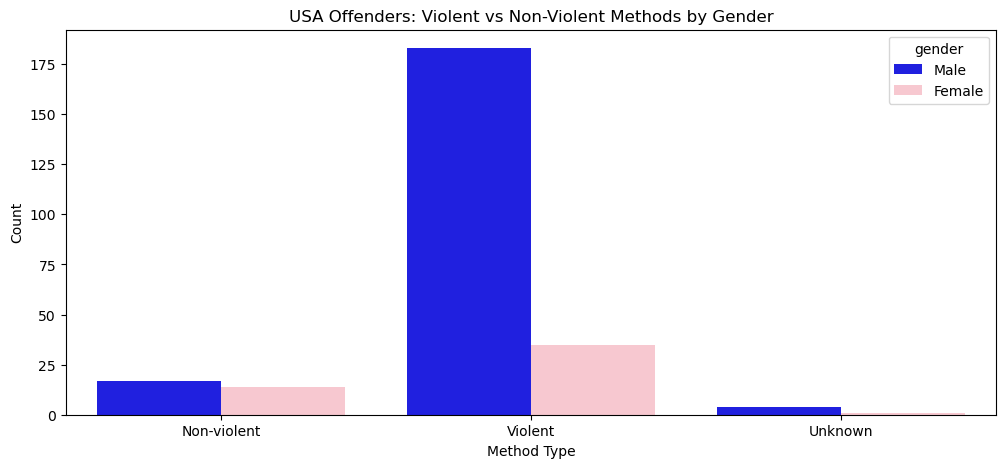

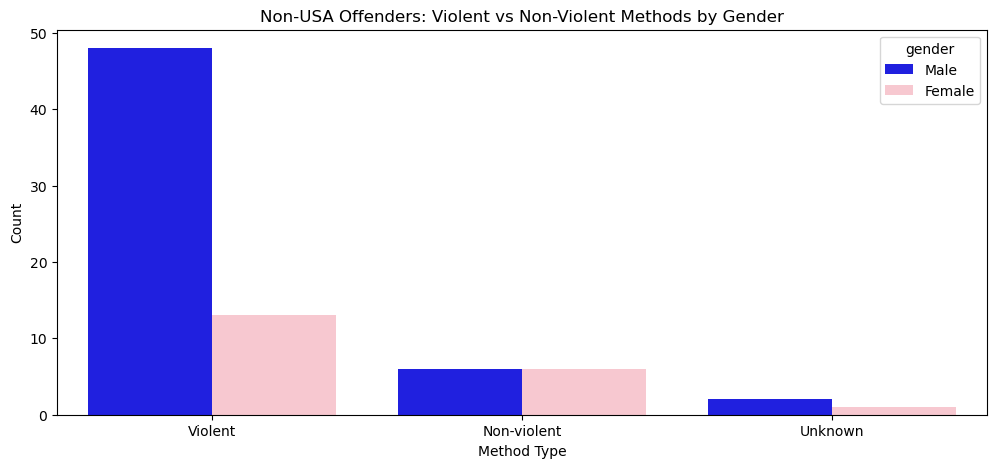

In [168]:
# My first graph will show Violent vs Non-Violent Methods by Gender and Location

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.countplot(data=final_df, x="violent_vs_nonviolent", hue="gender",palette={"Male": "blue", "Female": "pink"})

plt.title("USA Offenders: Violent vs Non-Violent Methods by Gender")
plt.xlabel("Method Type")
plt.ylabel("Count")
plt.savefig("Violent_Location_GenderUSA", dpi=300, bbox_inches="tight")
plt.show()

# Non-USA Graph
plt.figure(figsize=(12,5))

sns.countplot(data=final_df[final_df["usa_location"] == "Non-USA"],x="violent_vs_nonviolent",hue="gender",palette={"Male": "blue", "Female": "pink"})

plt.title("Non-USA Offenders: Violent vs Non-Violent Methods by Gender")
plt.xlabel("Method Type")
plt.ylabel("Count")
plt.savefig("Violent_Location_Gender", dpi=300, bbox_inches="tight")
plt.show()
#Regardless of location and Gender the most common method is violent

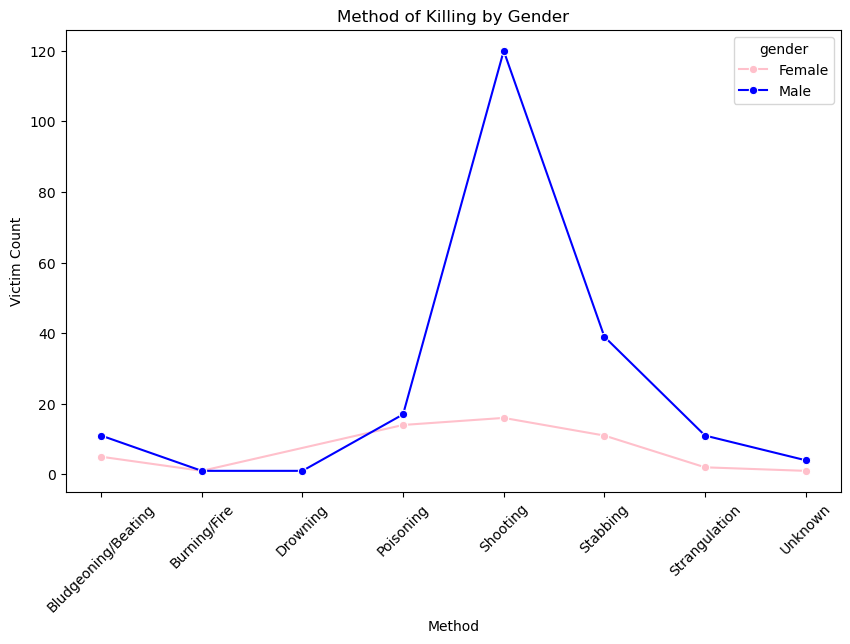

In [166]:
#My second graph is method of killing by gender and will be a line graph 
method_gender = ( final_df.groupby(["method", "gender"]).size().reset_index(name="count"))

plt.figure(figsize=(10,6))

sns.lineplot(data=method_gender,x="method",y="count",hue="gender",palette={"Male": "blue", "Female": "pink"},marker="o")

plt.title("Method of Killing by Gender")
plt.xlabel("Method")
plt.ylabel("Victim Count")

plt.xticks(rotation=45)
plt.savefig("method_vic.png", dpi=300, bbox_inches="tight")
plt.show()